In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
gdp = pd.read_csv('API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv', skiprows=4)

print(gdp.head())

                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code        1960        1961        1962        1963        1964  \
0  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
1  NY.GDP.PCAP.CD  186.089204  186.909053  197.367547  225.400079  208.962717   
2  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
3  NY.GDP.PCAP.CD  121.936832  127.451040  133.823783  139.004980  148.545883   
4  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   

         1965  ...          2017          2018    

In [8]:
#ensures we format data by country rather than year
gdp_long = gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(y) for y in range(2010, 2024)],
    var_name='year',
    value_name='gdp_per_capita'
)

gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long = gdp_long.dropna(subset=['gdp_per_capita'])
gdp_long.columns = ['country_name', 'country_code', 'year', 'gdp_per_capita']

print(gdp_long.head())

                  country_name country_code  year  gdp_per_capita
0                        Aruba          ABW  2010    24093.140151
1  Africa Eastern and Southern          AFE  2010     1628.905248
2                  Afghanistan          AFG  2010      560.621505
3   Africa Western and Central          AFW  2010     1662.633658
4                       Angola          AGO  2010     4101.637156


In [9]:
removals = pd.read_csv('removals_10yr.csv', usecols=['Departure Country', 'Departure Date'])

removals['year'] = pd.to_datetime(removals['Departure Date'], errors='coerce').dt.year

removals_by_country = removals.groupby(['Departure Country', 'year']).size().reset_index(name='removal_count')

print(removals_by_country.head())

  Departure Country  year  removal_count
0       AFGHANISTAN  2011              5
1       AFGHANISTAN  2012             18
2       AFGHANISTAN  2013             10
3       AFGHANISTAN  2014             20
4       AFGHANISTAN  2015              4


In [10]:
removals_by_country['country_name'] = removals_by_country['Departure Country'].str.title()

merged_gdp = pd.merge(
    removals_by_country,
    gdp_long,
    on=['country_name', 'year'],
    how='inner'
)

print(merged_gdp.shape)
print(merged_gdp.head())

(1611, 6)
  Departure Country  year  removal_count country_name country_code  \
0       AFGHANISTAN  2011              5  Afghanistan          AFG   
1       AFGHANISTAN  2012             18  Afghanistan          AFG   
2       AFGHANISTAN  2013             10  Afghanistan          AFG   
3       AFGHANISTAN  2014             20  Afghanistan          AFG   
4       AFGHANISTAN  2015              4  Afghanistan          AFG   

   gdp_per_capita  
0      606.694676  
1      651.417134  
2      637.087099  
3      625.054942  
4      565.569730  


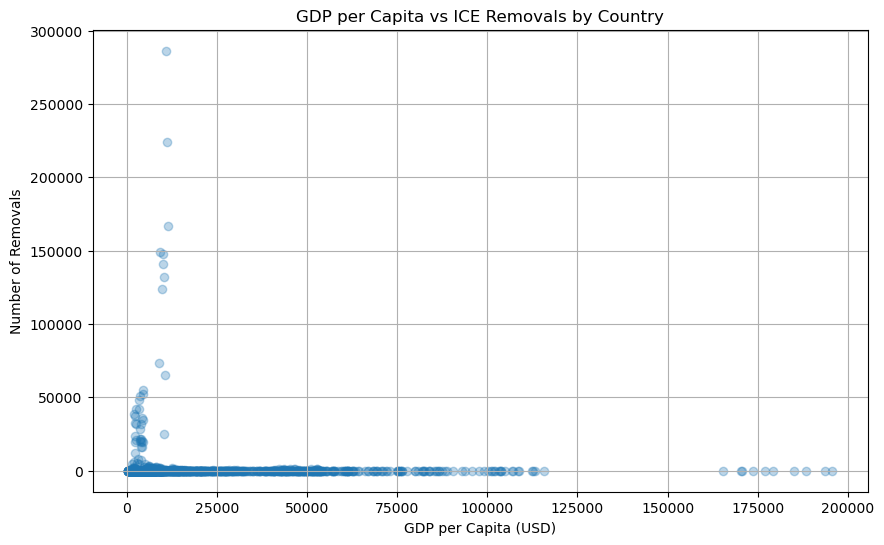

Correlation between GDP and removals: -0.041


In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_gdp['gdp_per_capita'], merged_gdp['removal_count'], alpha=0.3)
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Number of Removals')
plt.title('GDP per Capita vs ICE Removals by Country')
plt.grid(True)
plt.show()

# correlation
corr = merged_gdp['gdp_per_capita'].corr(merged_gdp['removal_count'])
print(f"Correlation between GDP and removals: {corr:.3f}")